# Análisis Comparativo de Causas de Mortalidad: Mundo vs. Colombia (2010-2017)

## 1. Objetivo

El objetivo de este análisis es evaluar el porcentaje de muertes atribuidas a diversas causas a nivel global en 2017, identificar la tendencia histórica de crecimiento (2010-2017) y contrastar la realidad mundial con los datos oficiales de Colombia (DANE), identificando brechas significativas.

## 2. Metodología y Calidad de Datos

* **Nota de Auditoría de Fechas:** La rúbrica inicial sugiere analizar la variación entre 2005 y 2010. Sin embargo, los metadatos reales del archivo suministrado corresponden a la variación anual entre 2010 y 2017. El análisis se ejecutará sobre este periodo real para garantizar la integridad de la información.

* **Integración de Fuentes (Enriquecimiento):** Dado que el conjunto de datos base presenta un nivel de agregación exclusivamente global, se inyectó una dimensión categórica externa consumiendo la **Taxonomía de la OMS (Clasificación Internacional de Enfermedades - CIE)**. Adicionalmente, se integraron los microdatos del **DANE (Cuadro 5 - Defunciones 2017)** para permitir la comparación nacional.

## 3. Arquitectura de Datos (Tubería ETL)

Para garantizar la reproducibilidad y el estándar de Ingeniería de Datos, el procesamiento de limpieza no se realizó en este documento. Se diseñó una tubería automatizada (ver carpeta `src/`):

1. **Extracción (`E_unpack_dane.py` / `E_make_dataset.py`):** Desempaquetado masivo de Excel y generación de diccionarios maestros (OMS y DANE).

2. **Transformación (`T_process_dataset.py`):** Estructuración de datos, normalización de textos y unificación de múltiples bases.

3. **Visualización (Este Documento):** Entorno dedicado exclusivamente al análisis sobre la capa de datos procesada final (`analytical_dataset.csv`).

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual (Estilo limpio para exportar a PDF)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Ingesta del conjunto de datos procesado
df = pd.read_csv("../data/processed/analytical_dataset.csv")

# ---------------------------------------------------------
# TRADUCCIÓN Y ESTANDARIZACIÓN AL ESPAÑOL
# ---------------------------------------------------------
df = df.rename(columns={
    'cause': 'causa',
    'who_category': 'categoria_oms',
    'pct_deaths_global': 'pct_muertes_global',
    'annual_change_global': 'cambio_anual_global',
    'pct_deaths_colombia': 'pct_muertes_colombia'
})

# Limpieza de nulos para las gráficas
df_limpio = df.dropna(subset=['pct_muertes_global', 'cambio_anual_global'])

print(f"Conjunto de datos cargado exitosamente. Total de causas analizadas: {len(df_limpio)}")

Conjunto de datos cargado exitosamente. Total de causas analizadas: 169


## 4. Panorama Global: Las causas más letales y la Matriz de Riesgo

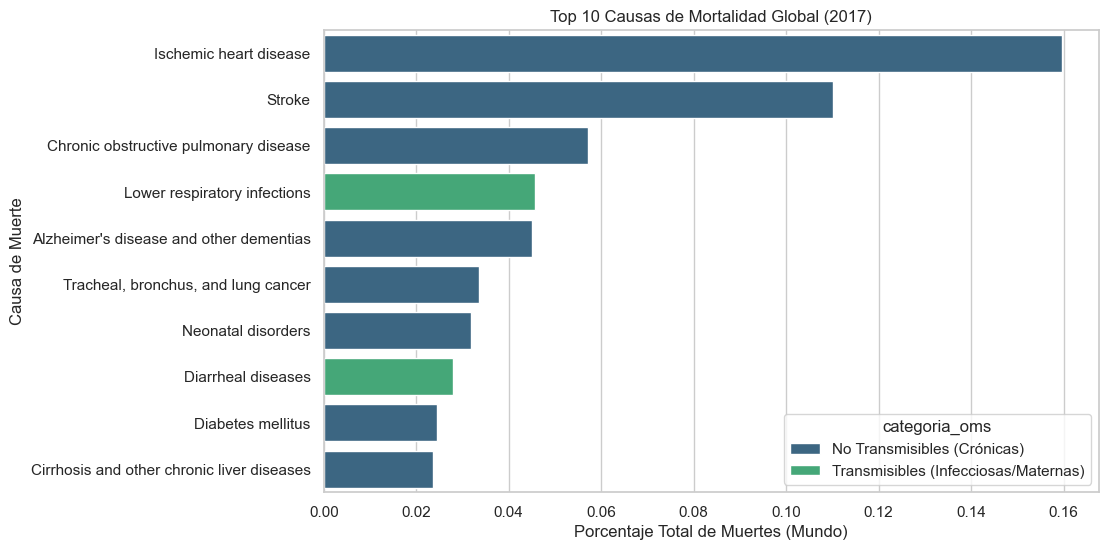

In [29]:
# Gráfico 1: Top 10 Causas Globales
top_10_causas = df_limpio.nlargest(10, 'pct_muertes_global')
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_causas, x='pct_muertes_global', y='causa', hue='categoria_oms', dodge=False, palette='viridis')
plt.title('Top 10 Causas de Mortalidad Global (2017)')
plt.xlabel('Porcentaje Total de Muertes (Mundo)')
plt.ylabel('Causa de Muerte')
plt.show()

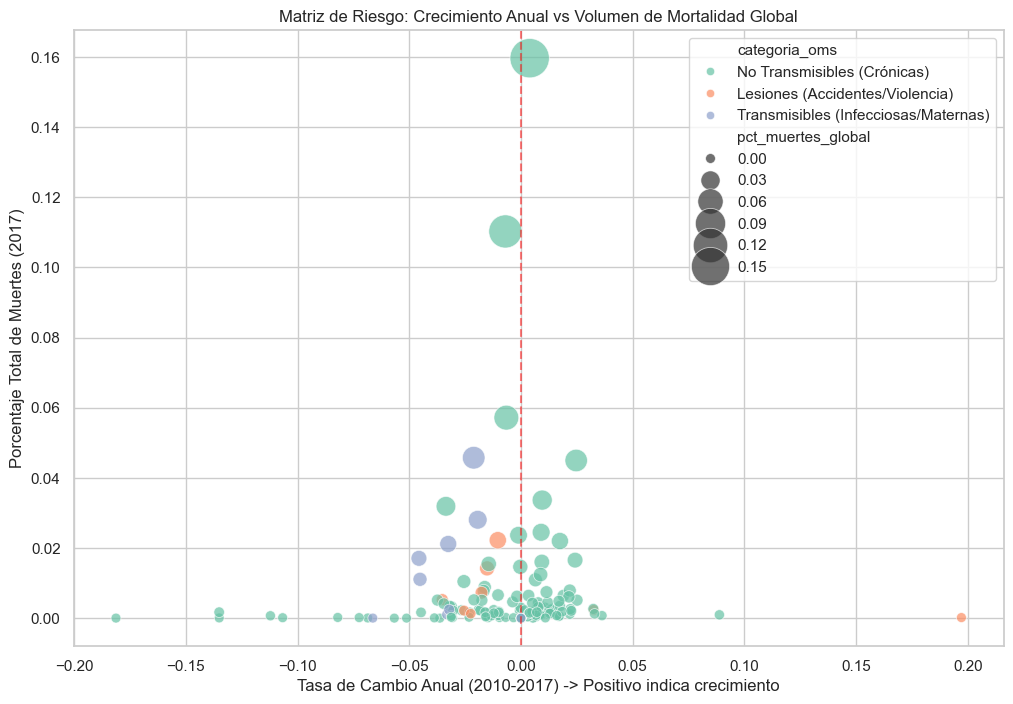

In [31]:
# Gráfico 2: Matriz de Riesgo y Tendencia
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_limpio, x='cambio_anual_global', y='pct_muertes_global',
    hue='categoria_oms', size='pct_muertes_global', sizes=(50, 800), alpha=0.7, palette='Set2'
)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.title('Matriz de Riesgo: Crecimiento Anual vs Volumen de Mortalidad Global')
plt.xlabel('Tasa de Cambio Anual (2010-2017) -> Positivo indica crecimiento')
plt.ylabel('Porcentaje Total de Muertes (2017)')
#plt.legend(title='Categoría OMS')
plt.show()

## 5. El Contexto Local: Colombia vs. El Mundo

Al cruzar las métricas mundiales con los datos del **DANE**, podemos identificar en qué aspectos Colombia se desvía del estándar global, lo cual es crítico para la focalización de recursos en salud.

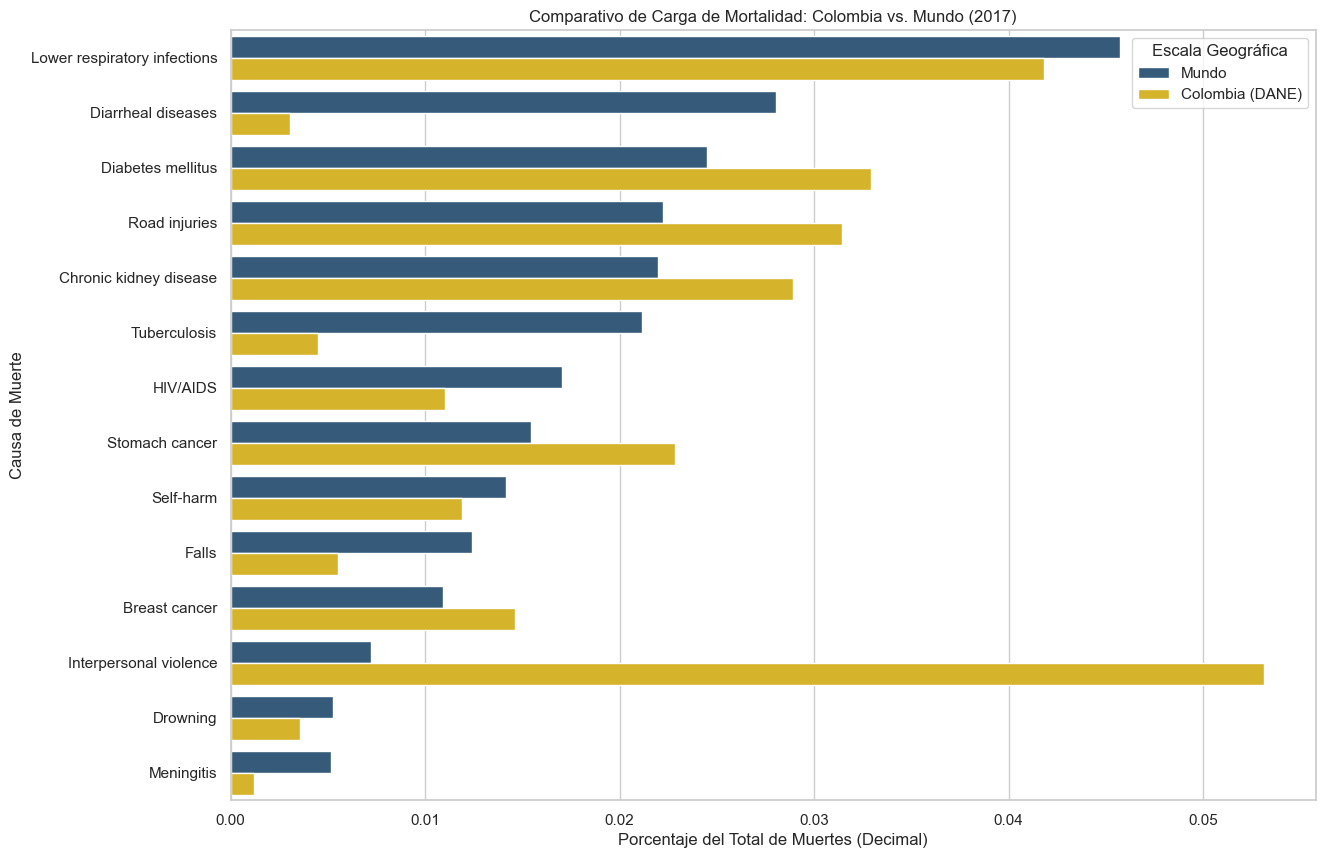

In [32]:
# Filtramos las causas con coincidencia en Colombia y preparamos los datos
df_comparativo = df.dropna(subset=['pct_muertes_colombia']).copy()

# Transformación a formato largo para poder graficar barras agrupadas
df_transformado = df_comparativo.melt(
    id_vars=['causa'], value_vars=['pct_muertes_global', 'pct_muertes_colombia'],
    var_name='Ubicacion', value_name='Porcentaje_Muertes'
)

# Renombrar valores para la leyenda en español
df_transformado['Ubicacion'] = df_transformado['Ubicacion'].replace({
    'pct_muertes_global': 'Mundo',
    'pct_muertes_colombia': 'Colombia (DANE)'
})

# Mantener el orden de mayor a menor impacto global
orden_causas = df_comparativo.sort_values('pct_muertes_global', ascending=False)['causa']

plt.figure(figsize=(14, 10))
sns.barplot(
    data=df_transformado, y='causa', x='Porcentaje_Muertes', hue='Ubicacion', 
    order=orden_causas, palette=['#2b5b84', '#f1c40f']
)
plt.title('Comparativo de Carga de Mortalidad: Colombia vs. Mundo (2017)')
plt.xlabel('Porcentaje del Total de Muertes (Decimal)')
plt.ylabel('Causa de Muerte')
plt.legend(title='Escala Geográfica')
plt.show()

In [33]:
# Cálculo de Hallazgos Numéricos (Diferencia en puntos porcentuales)
df_comparativo['diferencia_pp'] = (df_comparativo['pct_muertes_colombia'] - df_comparativo['pct_muertes_global']) * 100

mayor_riesgo = df_comparativo.loc[df_comparativo['diferencia_pp'].idxmax()]
mayor_control = df_comparativo.loc[df_comparativo['diferencia_pp'].idxmin()]

print("--- HALLAZGOS CRÍTICOS (COLOMBIA VS MUNDO) ---")
print(f"🔴 Mayor brecha NEGATIVA (Colombia está peor que el mundo):")
print(f"   {mayor_riesgo['causa']} supera el promedio global por +{mayor_riesgo['diferencia_pp']:.2f} puntos porcentuales.")
print("")
print(f"🟢 Mayor brecha POSITIVA (Colombia está mejor que el mundo):")
print(f"   {mayor_control['causa']} está por debajo del promedio global por {mayor_control['diferencia_pp']:.2f} puntos porcentuales.")

--- HALLAZGOS CRÍTICOS (COLOMBIA VS MUNDO) ---
🔴 Mayor brecha NEGATIVA (Colombia está peor que el mundo):
   Interpersonal violence supera el promedio global por +4.59 puntos porcentuales.

🟢 Mayor brecha POSITIVA (Colombia está mejor que el mundo):
   Diarrheal diseases está por debajo del promedio global por -2.50 puntos porcentuales.


## 6. Limitaciones del Estudio

* La homologación entre las causas globales (en inglés) y las listas tabuladas del DANE (CIE-10 agrupada) requirió mapeo manual. No todas las causas mundiales tienen una equivalencia estricta de 1 a 1 en el resumen del DANE.

* El análisis compara porcentajes relativos sobre el total de muertes, no tasas estandarizadas ajustadas por edad, lo que puede verse influenciado por la pirámide poblacional de Colombia frente a la media mundial.

## 7. Conclusión: La Transición Epidemiológica

A partir del análisis multivariado, se evidencia un fenómeno demográfico claro:

1. **El control sobre las infecciones:** Las causas catalogadas por la OMS como *Transmisibles* (Infecciones, Tuberculosis, VIH) se ubican casi en su totalidad con tasas de cambio negativas. Están en declive sostenido.

2. **La carga de la modernidad:** Por el contrario, las enfermedades *No Transmisibles* (Crónicas/Cardiovasculares) no solo dominan el ranking de volumen, sino que muestran crecimiento positivo. 

3. **La anomalía de Colombia:** Mientras el mundo lidia con enfermedades del envejecimiento, el análisis de brechas demuestra que Colombia tiene una sobre-representación extrema en muertes por **Violencia Interpersonal (Homicidios)**, alejándose radicalmente del comportamiento global.

## 8. Recomendación Estratégica de Política Pública

A la luz de los datos, los sistemas de salud pública deben realizar un doble reajuste. A nivel general, la inversión futura debe volcarse hacia la prevención del sedentarismo y el control de enfermedades cardiovasculares. Sin embargo, para el **caso específico de Colombia**, la mayor fuga de capital humano y años de vida potencialmente perdidos no obedece a un factor biológico, sino de seguridad. Cualquier política de salud pública en Colombia debe estar fuertemente entrelazada con políticas de seguridad civil, desarme y resolución de conflictos.